# [P08] Week 4: Critical Minerals Supply Chain - Deterministic and Multi-Objective Optimization

**1. Objective:**  Formulate the mine-to-market network-flow LP/MILP over network.json. Minimize logistics cost subject to mine, processing, and port capacity constraints and demand-satisfaction constraints, using supply_chain_monthly.csv for cost and capacity parameters. Solve the cost-minimal flow in PuLP, then build a three-objective Pareto frontier across cost, delivery reliability, and carbon footprint, using epsilon-constraint.

**2. Inputs Required:**
* `supply_chain_monthly.csv`
* `network.json`

**3. Outputs Produced:**
* `week4_pareto_results.csv`

**4. Foundation Papers Implemented:**
* Moradi Afrapoli, A., & Askari-Nasab, H. (2019/2022). Advanced analytics for surface extraction.
* Hazrathosseini, A., & Moradi Afrapoli, A. (2024). Maximizing mining operations.

### Importing Libraries and Loading Data

In [34]:
# WHAT: Import analytical, optimization libraries.
# INPUT: None (Standard libraries)
# OUTPUT: Loaded modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from pulp import *
import json
import warnings
warnings.filterwarnings('ignore')

In [17]:
# Load network graph
with open('network.json') as f:
    net = json.load(f)

nodes     = {n['id']: n for n in net['nodes']}
arc_dict  = {(a['from'], a['to']): a for a in net['arcs']}
customers = [n['id'] for n in net['nodes'] if n['type'] == 'customer']
arcs_list = [(a['from'], a['to']) for a in net['arcs']]

# Load historical CSV
df = pd.read_csv('supply_chain_monthly.csv', parse_dates=['month'])

### Deriving Planning Parameters

In [18]:
# Capacity parameters: 90th-percentile (robust planning)
MINE_CAP     = df['mine_output_kt'].quantile(0.90)
PROC_CAP     = df['processing_cap_kt'].quantile(0.90)
PORT_CAP     = df['port_capacity_kt'].quantile(0.90)
TOTAL_DEMAND = df['demand_kt'].mean()

# Customer demand split: inversely proportional to shipping cost
inv_costs = {c: 1 / arc_dict[('PORT', c)]['cost_per_t'] for c in customers}
total_inv = sum(inv_costs.values())
demand    = {c: TOTAL_DEMAND * inv_costs[c] / total_inv for c in customers}

### Building the LP

#### Mathematical Formulation of the Network Flow Optimization Model

This supply chain is modeled as a deterministic minimum-cost network flow problem. Material flows from the Mine to the Processing Facility, then to the Port, and finally to Customers. The objective is to determine the optimal shipment quantities that minimize logistics cost while satisfying capacity and flow conservation constraints.

##### Decision Variables

Let

$$
x_{ij}
$$

represent the quantity of critical mineral transported from node \(i\) to node \(j\).

For example,

$$
x_{\text{MINE,PROC}}
$$

denotes the quantity shipped from the Mine to the Processing Facility.

---

##### Objective Function

The objective is to minimize total transportation cost across the network:

$$
\min Z =
\sum_{(i,j)\in A}
c_{ij}x_{ij}
$$

where:

- \(c_{ij}\) = transportation cost per unit shipped along arc \(i \rightarrow j\)
- \(x_{ij}\) = shipment quantity
- \(A\) = set of all transportation arcs

---

##### Capacity Constraints

The flow on each stage cannot exceed available capacity.

##### Mine Capacity

$$
x_{\text{MINE,PROC}}
\leq
\text{Mine Capacity}
$$

##### Processing Capacity

$$
x_{\text{PROC,PORT}}
\leq
\text{Processing Capacity}
$$

##### Port Capacity

$$
\sum_{c}
x_{\text{PORT},c}
\leq
\text{Port Capacity}
$$

---

##### Flow Conservation Constraints

Material cannot be created or destroyed within the network.

At the Processing Facility:

$$
x_{\text{MINE,PROC}}
=
x_{\text{PROC,PORT}}
$$

At the Port:

$$
x_{\text{PROC,PORT}}
=
\sum_{c}
x_{\text{PORT},c}
$$

---

##### Demand Fulfilment

Customer demand must be satisfied through outbound shipments from the Port.

For every customer \(c\):

$$
x_{\text{PORT},c}
\geq
D_c
$$

where:

- \(D_c\) = demand of customer \(c\)

---

##### Model Output

The optimization model determines the least-cost feasible flow of critical minerals through the supply chain while respecting production, processing, and export constraints.

In [19]:
prob = LpProblem("MineToMarket_CostMin", LpMinimize)

# Decision variables: one per arc
x = {(f, t): pulp.LpVariable(f"x_{f}_{t}", lowBound=0)
     for (f, t) in arcs_list}

In [20]:
# Objective: minimize total logistics cost
cost_expr = pulp.lpSum(arc_dict[(f, t)]['cost_per_t'] * x[(f, t)]
                       for (f, t) in arcs_list)
ghg_expr  = pulp.lpSum(arc_dict[(f, t)]['ghg_t_per_t'] * x[(f, t)]
                       for (f, t) in arcs_list)
prob += cost_expr, "TotalCost"

In [21]:
# Constraints
prob += x[('MINE', 'PROC')] <= MINE_CAP,  "C_MineCapacity"
prob += x[('PROC', 'PORT')] <= PROC_CAP,  "C_ProcCapacity"
prob += pulp.lpSum(x[('PORT', c)] for c in customers) <= PORT_CAP, "C_PortCapacity"
prob += x[('MINE', 'PROC')] == x[('PROC', 'PORT')], "C_MassBalance_1"
prob += x[('PROC', 'PORT')] == pulp.lpSum(x[('PORT', c)] for c in customers), "C_MassBalance_2"
for c in customers:
    prob += x[('PORT', c)] >= demand[c], f"C_Demand_{c}"

### Solving

In [22]:
prob.solve(pulp.PULP_CBC_CMD(msg=0))

print(f"Solver status : {LpStatus[prob.status]}")
print(f"Total cost    : ${pulp.value(cost_expr):,.0f} $/month")
print(f"Total GHG     : {pulp.value(ghg_expr):.4f} kt CO₂/month")

for (f, t) in arcs_list:
    flow = x[(f, t)].varValue
    cost = arc_dict[(f, t)]['cost_per_t'] * flow
    print(f"  {f}→{t}: {flow:.2f} kt  |  ${cost:,.0f}")

Solver status : Optimal
Total cost    : $21,165 $/month
Total GHG     : 16.4610 kt CO₂/month
  MINE→PROC: 298.20 kt  |  $2,386
  PROC→PORT: 298.20 kt  |  $3,578
  PORT→CUS1: 112.60 kt  |  $5,067
  PORT→CUS2: 120.64 kt  |  $5,067
  PORT→CUS3: 64.96 kt  |  $5,067


In [23]:
# Shadow prices
for name, c in prob.constraints.items():
    if c.pi is not None and abs(c.pi) > 1e-6:
        print(f"  {name}: {c.pi:.2f}")

  C_MassBalance_1: 8.00
  C_MassBalance_2: 20.00
  C_Demand_CUS1: 65.00
  C_Demand_CUS2: 62.00
  C_Demand_CUS3: 98.00


In [24]:
BASELINE_GHG = pulp.value(ghg_expr)

print("Baseline GHG:", BASELINE_GHG)

Baseline GHG: 16.461011234


### Network Flow Diagram

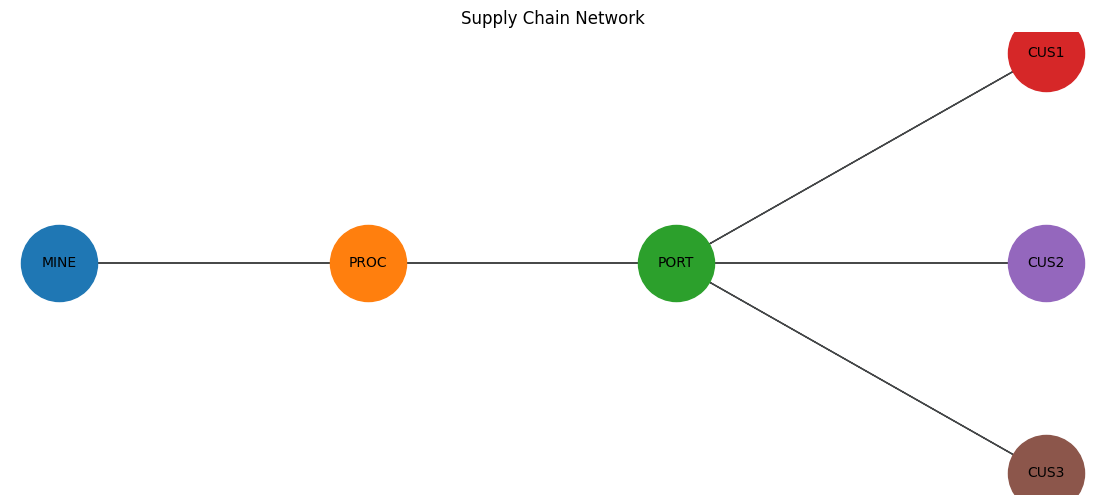

In [25]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.axis('off')

node_pos = {
    'MINE': (0,0), 'PROC': (1.5,0), 'PORT': (3,0),
    'CUS1': (4.8,1.2), 'CUS2': (4.8,0), 'CUS3': (4.8,-1.2)
}

for node, (xpos, ypos) in node_pos.items():

    ax.scatter(
        xpos,
        ypos,
        s=3000,
        zorder=3
    )

    ax.text(
        xpos,
        ypos,
        node,
        ha="center",
        va="center"
    )

for (f, t) in arcs_list:

    x1, y1 = node_pos[f]
    x2, y2 = node_pos[t]

    ax.arrow(
        x1,
        y1,
        x2 - x1,
        y2 - y1,
        length_includes_head=True,
        head_width=0.08,
        alpha=0.7
    )

plt.title("Supply Chain Network")
plt.show()

### Multi-Objective Optimization using the Epsilon-Constraint Method

While minimizing logistics cost is important, supply chain decisions must also consider environmental sustainability and service reliability.

This section extends the optimization model into a multi-objective framework by simultaneously evaluating:

1. Total Logistics Cost
2. Greenhouse Gas (GHG) Emissions
3. Customer Service Reliability

Because these objectives can conflict with one another, the Epsilon-Constraint Method is used to generate Pareto-optimal solutions.

---

#### Cost Objective

The primary objective remains the minimization of transportation cost:

$$
\min Cost =
\sum_{(i,j)\in A}
c_{ij}x_{ij}
$$

where:

- \(c_{ij}\) = transportation cost per unit shipped
- \(x_{ij}\) = shipment quantity

---

#### Greenhouse Gas Emissions

Total emissions generated by transportation activities are computed as:

$$
GHG =
\sum_{(i,j)\in A}
e_{ij}x_{ij}
$$

where:

- \(e_{ij}\) = emission factor associated with arc \(i \rightarrow j\)

---

#### Reliability Metric

Supply chain reliability is defined as the proportion of total demand that is successfully fulfilled.

$$
Reliability =
\frac{
\text{Delivered Quantity}
}{
\text{Total Demand}
}
\times 100
$$

A reliability value of 100% indicates complete fulfilment of customer demand.

---

#### Epsilon-Constraint Formulation

Instead of minimizing cost and emissions simultaneously, emissions are converted into a constraint:

$$
GHG \leq \varepsilon
$$

where:

- \(\varepsilon\) = allowable emissions threshold

The optimization problem therefore becomes:

$$
\min Cost
$$

subject to:

$$
GHG \leq \varepsilon
$$

and all network flow constraints.

---

#### Pareto Frontier Generation

Multiple optimization runs are performed using different values of:

- Reliability target
- Emission threshold (\(\varepsilon\))

Each run produces a feasible solution with a unique combination of:

- Cost
- Emissions
- Reliability

The collection of these solutions forms an approximation of the Pareto Frontier, allowing decision-makers to evaluate trade-offs between economic performance, sustainability, and customer service levels.

---

#### Managerial Insight

The Pareto Frontier provides decision-makers with a range of feasible operating strategies:

- **Cost-focused strategy:** Lower transportation costs but reduced reliability.
- **Reliability-focused strategy:** Higher customer service levels with increased logistics expenditure.
- **Sustainability-focused strategy:** Reduced emissions at the expense of higher operational cost.

This enables informed decision-making based on organizational priorities and strategic objectives.

In [26]:
def solve_epsilon(min_reliability_frac, eps_ghg):

    _prob = pulp.LpProblem("EP", pulp.LpMinimize)

    _x = {
        (f, t): pulp.LpVariable(
            f"x_{f}_{t}",
            lowBound=0
        )
        for (f, t) in arcs_list
    }

    _cost = pulp.lpSum(
        arc_dict[(f, t)]["cost_per_t"] * _x[(f, t)]
        for (f, t) in arcs_list
    )

    _ghg = pulp.lpSum(
        arc_dict[(f, t)]["ghg_t_per_t"] * _x[(f, t)]
        for (f, t) in arcs_list
    )

    _prob += _cost

    # Capacity constraints
    _prob += _x[("MINE", "PROC")] <= MINE_CAP
    _prob += _x[("PROC", "PORT")] <= PROC_CAP
    _prob += pulp.lpSum(
        _x[("PORT", c)]
        for c in customers
    ) <= PORT_CAP

    # Mass balance
    _prob += (
        _x[("MINE", "PROC")]
        ==
        _x[("PROC", "PORT")]
    )

    _prob += (
        _x[("PROC", "PORT")]
        ==
        pulp.lpSum(
            _x[("PORT", c)]
            for c in customers
        )
    )

    # Reliability
    for c in customers:
        _prob += (
            _x[("PORT", c)]
            >=
            min_reliability_frac * demand[c]
        )

    # GHG cap
    _prob += _ghg <= eps_ghg

    _prob.solve(pulp.PULP_CBC_CMD(msg=0))

    if _prob.status != 1:
        return None

    shipped = sum(
        _x[("PORT", c)].varValue
        for c in customers
    )

    return {
        "cost": pulp.value(_cost),
        "ghg": pulp.value(_ghg),
        "reliability": (
            shipped / TOTAL_DEMAND
        ) * 100
    }

In [28]:
import pulp

print(pulp)
print(pulp.__file__)
print(hasattr(pulp, "LpMinimize"))

<module 'pulp' from 'c:\\Users\\Sri Vaishnavi\\AppData\\Local\\Programs\\Python\\Python313\\Lib\\site-packages\\pulp\\__init__.py'>
c:\Users\Sri Vaishnavi\AppData\Local\Programs\Python\Python313\Lib\site-packages\pulp\__init__.py
True


### Grid Scan

#### Pareto Frontier Generation

A grid search is performed over:

- Reliability targets from 50% to 100%
- Emission caps from 80% to 130% of baseline emissions

For each combination:

1. Solve optimization model
2. Record cost
3. Record emissions
4. Record achieved reliability

The resulting solution set approximates the Pareto Frontier.

In [29]:
reliability_levels = np.linspace(0.50, 1.00, 11)   # 50% → 100%
ghg_levels         = np.linspace(0.80, 1.30, 10)   # 80% → 130% of baseline GHG

pareto_points = []
for rel in reliability_levels:
    for ghg_frac in ghg_levels:
        result = solve_epsilon(rel, BASELINE_GHG * ghg_frac)
        if result:
            pareto_points.append(result)

pareto_df = pd.DataFrame(pareto_points).drop_duplicates().sort_values('cost').reset_index(drop=True)

### Three Pareto Plots

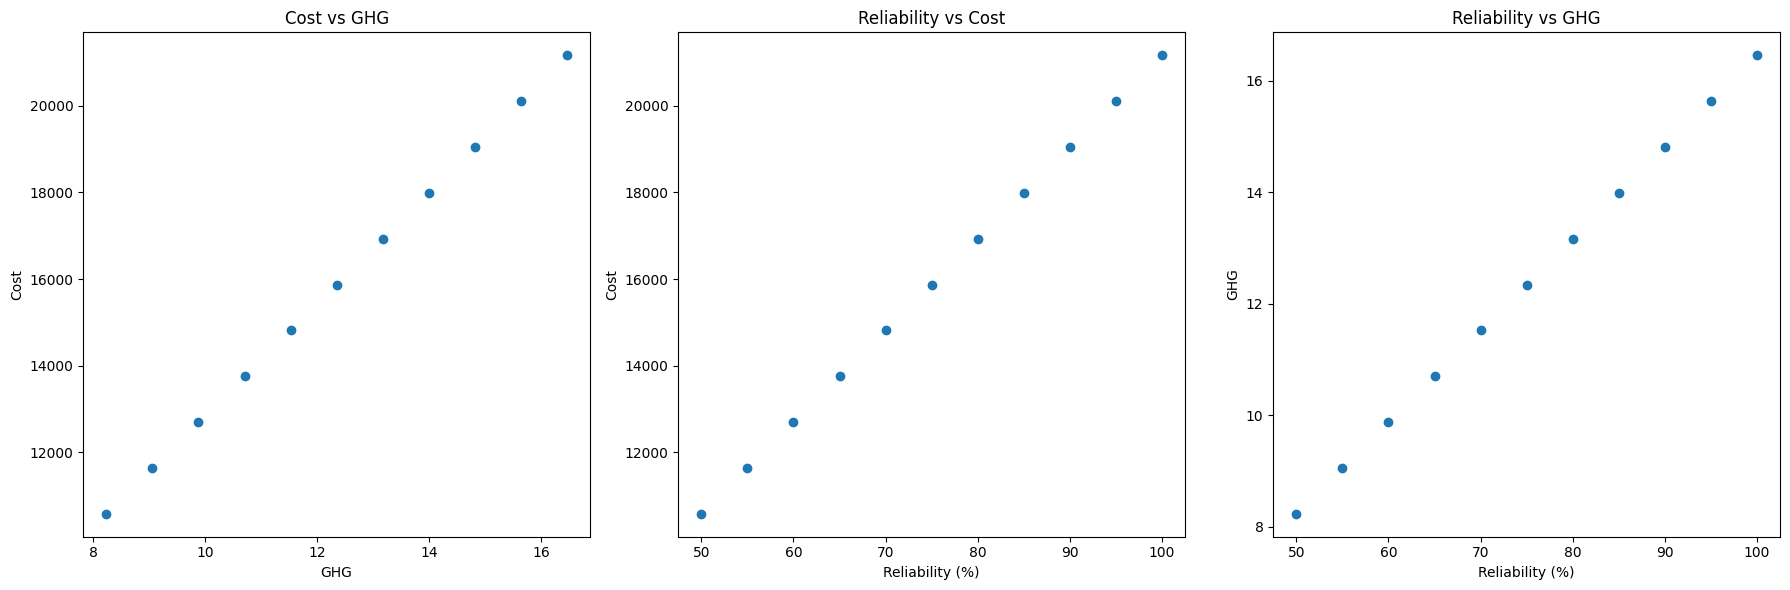

In [32]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 6)
)

# Cost vs GHG
axes[0].scatter(
    pareto_df["ghg"],
    pareto_df["cost"]
)
axes[0].set_xlabel("GHG")
axes[0].set_ylabel("Cost")
axes[0].set_title("Cost vs GHG")

# Reliability vs Cost
axes[1].scatter(
    pareto_df["reliability"],
    pareto_df["cost"]
)
axes[1].set_xlabel("Reliability (%)")
axes[1].set_ylabel("Cost")
axes[1].set_title("Reliability vs Cost")

# Reliability vs GHG
axes[2].scatter(
    pareto_df["reliability"],
    pareto_df["ghg"]
)
axes[2].set_xlabel("Reliability (%)")
axes[2].set_ylabel("GHG")
axes[2].set_title("Reliability vs GHG")

plt.tight_layout()
plt.show()

### Saving Outputs

In [33]:
pareto_df.to_csv('week4_pareto_results.csv', index=False)

### Summary

#### Key Performance Indicator (KPI)

| KPI | Value | Operational Interpretation |
|-------|-------|-------|
| Minimum Logistics Cost | See Solver Output | Lowest achievable transportation cost while satisfying network constraints |
| Baseline GHG Emissions | See Solver Output | Reference environmental footprint of the optimized supply chain |
| Reliability (%) | See Pareto Results | Fraction of customer demand successfully fulfilled |
| Binding Constraints | Shadow Price Analysis | Indicates bottlenecks restricting throughput |
| Mine Capacity Utilization | Computed from LP Solution | Measures upstream production stress |
| Processing Capacity Utilization | Computed from LP Solution | Indicates processing bottlenecks |
| Port Capacity Utilization | Computed from LP Solution | Measures export terminal congestion |
| Pareto Solutions Generated | len(pareto_df) | Number of feasible trade-off scenarios discovered |

#### Operational Interpretation

The optimization identifies the least-cost flow of critical minerals through the supply chain while respecting production, processing, and export constraints.

The shadow-price analysis highlights which facilities are constraining system performance and quantifies the economic value of additional capacity.

The Pareto analysis demonstrates the trade-off between service reliability and sustainability objectives. Higher reliability requires greater material throughput, increasing both logistics cost and greenhouse-gas emissions.

Managers can therefore select operating points that align with strategic priorities:

- Cost Leadership → Lower reliability, lower emissions
- Service Excellence → Higher reliability, higher cost
- Sustainability Focus → Lower emission caps with moderate reliability

This framework provides a decision-support tool for balancing economic, environmental, and service-performance objectives in critical-mineral supply chains.